In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
data_path = os.path.join("data")

# obtener los archivos excel
excel_files = [f for f in os.listdir(data_path) if f.endswith('.xlsx')]

dataframes = {}
for file in excel_files:
    file_path = os.path.join(data_path, file)
    # Usar el nombre del archivo sin extensión como clave
    df_name = file.replace('.xlsx', '')
    dataframes[df_name] = pd.read_excel(file_path)
    print(f"Cargado: {file}")

# mostramos los dataframes cargados
print(f"\nTotal de archivos cargados: {len(dataframes)}")
print(f"Dataframes disponibles: {list(dataframes.keys())}")


Cargado: LaLiga19 20.xlsx
Cargado: LaLiga21 22.xlsx
Cargado: LaLiga17 18.xlsx
Cargado: LaLiga20 21.xlsx
Cargado: LaLiga16 17.xlsx
Cargado: LaLiga18 19.xlsx

Total de archivos cargados: 6
Dataframes disponibles: ['LaLiga19 20', 'LaLiga21 22', 'LaLiga17 18', 'LaLiga20 21', 'LaLiga16 17', 'LaLiga18 19']


In [12]:
dataframes.keys()

dict_keys(['LaLiga19 20', 'LaLiga21 22', 'LaLiga17 18', 'LaLiga20 21', 'LaLiga16 17', 'LaLiga18 19'])

In [13]:
display(dataframes['LaLiga19 20'].head())

,Wk,Day,Date,Time,Local,xG,Score,xG.1,Visitante,Attendance,Venue,Referee,Informe del partido,Notes
0,1.0,Vie,2019-08-16,21:00 (15:00),Athletic Club,0.5,1–0,0.9,Barcelona,47.693,San Mamés,Carlos del Cerro,Informe del partido,NaN
1,1.0,Sáb,2019-08-17,17:00 (11:00),Celta Vigo,0.8,1–3,1.5,Real Madrid,23.566,Estadio de Balaídos,Javier Estrada,Informe del partido,NaN
2,1.0,Sáb,2019-08-17,19:00 (13:00),Valencia,2.3,1–1,1.3,Real Sociedad,41.846,Estadio de Mestalla,Jesús Gil,Informe del partido,NaN
3,1.0,Sáb,2019-08-17,20:00 (14:00),Mallorca,1.7,2–1,0.7,Eibar,15.127,Iberostar Estadi,Mario Melero,Informe del partido,NaN
4,1.0,Sáb,2019-08-17,21:00 (15:00),Villarreal,1.6,4–4,2.2,Granada,14.753,Estadio de la Cerámica,Adrián Cordero,Informe del partido,NaN


In [14]:
equipos = ['Real Madrid', 'Barcelona']
columnas_a_borrar = ['Day', 'Time', 'xG', 'xG.1', 'Referee', 'Informe del partido', 'Notes']

dataframes_filtrados = {}

for key, df in dataframes.items():
    filtro = df['Local'].isin(equipos) | df['Visitante'].isin(equipos) #que el local o el visitante esté en los equipos
    df_filtrado = df[filtro]
    df_limpio = df_filtrado.drop(columns=columnas_a_borrar, errors='ignore') #eliminar las columnas que no son de interes
    dataframes_filtrados[key] = df_limpio #guardo el cambio

# verificamos que el dataframe este ok
display(dataframes_filtrados['LaLiga19 20'].head())

,Wk,Date,Local,Score,Visitante,Attendance,Venue
0,1.0,2019-08-16,Athletic Club,1–0,Barcelona,47.693,San Mamés
1,1.0,2019-08-17,Celta Vigo,1–3,Real Madrid,23.566,Estadio de Balaídos
14,2.0,2019-08-24,Real Madrid,1–1,Valladolid,63.037,Estadio Santiago Bernabéu
20,2.0,2019-08-25,Barcelona,5–2,Betis,79.159,Camp Nou
24,3.0,2019-08-31,Osasuna,2–2,Barcelona,16.742,Estadio El Sadar


In [20]:
lista_goles_por_año = []

equipos = ['Real Madrid', 'Barcelona']

for temporada, df in dataframes_filtrados.items():
    df_temp = df.copy()
    df_temp[['Goles_Local', 'Goles_Visitante']] = df_temp['Score'].astype(str).str.split(r'[-–]', expand=True).astype(float)
    
    datos_equipos = []
    
    # ciclo para calcular goles por equipo
    for equipo in equipos:
        goles_local = df_temp[df_temp['Local'] == equipo]['Goles_Local'].sum()
        goles_visita = df_temp[df_temp['Visitante'] == equipo]['Goles_Visitante'].sum()
        datos_equipos.append({
            'Temporada': temporada,
            'Equipo': equipo,
            'Goles Local': int(goles_local),
            'Goles Visita': int(goles_visita),
            'Goles Totales': int(goles_local + goles_visita)
        })

    df_resumen_año = pd.DataFrame(datos_equipos)
    lista_goles_por_año.append(df_resumen_año)

print("Resumen de la primera temporada procesada:")
for df in lista_goles_por_año:
    print('='*62)
    display(df)

Resumen de la primera temporada procesada:


,Temporada,Equipo,Goles Local,Goles Visita,Goles Totales
0,LaLiga19 20,Real Madrid,40,30,70
1,LaLiga19 20,Barcelona,52,34,86


,Temporada,Equipo,Goles Local,Goles Visita,Goles Totales
0,LaLiga21 22,Real Madrid,44,36,80
1,LaLiga21 22,Barcelona,37,31,68


,Temporada,Equipo,Goles Local,Goles Visita,Goles Totales
0,LaLiga17 18,Real Madrid,54,40,94
1,LaLiga17 18,Barcelona,53,46,99


,Temporada,Equipo,Goles Local,Goles Visita,Goles Totales
0,LaLiga20 21,Real Madrid,33,34,67
1,LaLiga20 21,Barcelona,44,41,85


,Temporada,Equipo,Goles Local,Goles Visita,Goles Totales
0,LaLiga16 17,Real Madrid,48,58,106
1,LaLiga16 17,Barcelona,64,52,116


,Temporada,Equipo,Goles Local,Goles Visita,Goles Totales
0,LaLiga18 19,Real Madrid,32,31,63
1,LaLiga18 19,Barcelona,51,39,90


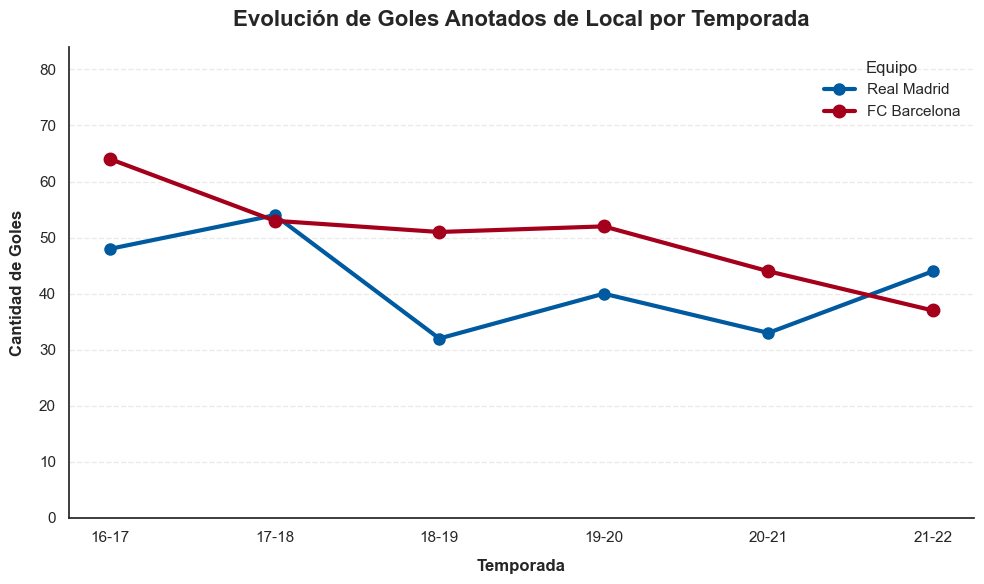

In [23]:
df_goles = pd.concat(lista_goles_por_año, ignore_index=True)

# limpiamos el texto de  LaLiga16 17" a "16-17
df_goles['Temporada_Corta'] = df_goles['Temporada'].str.replace('LaLiga', '').str.replace(' ', '-')

# ordenamos cronológicamente para que el gráfico tenga sentido de izquierda a derecha
df_goles = df_goles.sort_values('Temporada_Corta')

# separamos la data por equipo para facilitar el trazado de las líneas
df_rm = df_goles[df_goles['Equipo'] == 'Real Madrid']
df_fcb = df_goles[df_goles['Equipo'] == 'Barcelona']


sns.set_theme(style="white") # menos es mas
plt.figure(figsize=(10, 6))

# madrid
plt.plot(df_rm['Temporada_Corta'], df_rm['Goles Local'], marker='o', markersize=8, 
         color="#005A9F", linewidth=3, label='Real Madrid')

# barcelona
plt.plot(df_fcb['Temporada_Corta'], df_fcb['Goles Local'], marker='o', markersize=9, 
         color="#A5001B", linewidth=3, label='FC Barcelona')

# NO CORTAMOS EL EJE Y
max_goles = df_goles['Goles Local'].max() + 20 # Margen para que respire
plt.ylim(0, max_goles)

plt.title('Evolución de Goles Anotados de Local por Temporada', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Temporada', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Cantidad de Goles', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# eficiencia visual: retiramos los bordes innecesarios y agregamos guía horizontal
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Equipo', title_fontsize='12', fontsize='11', 
           loc='upper right', frameon=False)

plt.tight_layout()

# exportamos el grafco para usarlo luego en index.html y lo mostramos acá por gusto
plt.savefig('grafico_localia.png', dpi=300, bbox_inches='tight')
plt.show()